In [ ]:
import pandas as pd
from tqdm import tqdm
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import cast

import mlflow
from mlflow.entities import Trace, Span, SpanType
from loguru import logger

mlflow.set_tracking_uri("http://100.113.186.28:5000")
mlflow.set_experiment("vds-agent-validation")


In [ ]:
traces = cast(list, mlflow.search_traces(
        locations=['6'],
        filter_string="trace.text LIKE '%I want%'",
        return_type='list'
))
print(f"Loaded {len(traces)} traces")

In [ ]:
model2cost = {
    'OpenRouter/qwen/qwen3.6-plus': {
        'input_cost': {"<=256000": 0.325, ">256000": 1.30},
        "output_cost": {"<=256000": 1.95, ">256000": 3.90}
    },
    "OpenRouter/z-ai/glm-5.1": {
        "input_cost": 0.95,
        "output_cost": 3.15
    },
    "OpenRouter/qwen/qwen3.5-flash-02-23": {
        "input_cost": 0.065,
        "output_cost": 0.26
    },
    "OpenRouter/google/gemini-3.1-flash-lite-preview": {
        "input_cost": 0.25,
        "output_cost": 1.50
    },
    "OpenRouter/qwen/qwen3.5-27b": {
        "input_cost": 0.195,
        "output_cost": 1.56
    },
    "OpenRouter/qwen/qwen3.5-plus-02-15": {
        'input_cost': {"<=256000": 0.26, ">256000": 1.56},
        "output_cost": {"<=256000": 0.325, ">256000": 1.95}
    }
}


In [ ]:
def get_cost(model_key, input_tokens, output_tokens):
    """Calculates cost based on model pricing rules (per 1M tokens)."""
    if model_key not in model2cost:
        return 0.0
    pricing = model2cost[model_key]
    if isinstance(pricing['input_cost'], dict):
        tier = "<=256000" if input_tokens <= 256000 else ">256000"
        i_rate = pricing['input_cost'][tier]
        o_rate = pricing['output_cost'][tier]
    else:
        i_rate = pricing['input_cost']
        o_rate = pricing['output_cost']
    return (input_tokens * i_rate / 1_000_000) + (output_tokens * o_rate / 1_000_000)

In [ ]:
from collections import defaultdict
all_traces_summary = []
global_models = defaultdict(lambda: {
    'input_tokens': 0, 'output_tokens': 0, 'total_tokens': 0, 
    'call_count': 0, 'total_cost': 0.0
})

In [ ]:
for trace in tqdm(traces, desc="Iterating traces"):
    trace_id = trace.info.trace_id
    trace_record = {
        'trace_id': trace_id,
        'total_input_tokens': 0,
        'total_output_tokens': 0,
        'total_cost': 0.0,
        'model_calls': defaultdict(int),
        'model_costs': defaultdict(float)
    }
    for span in trace.data.spans:
        attrs = span.attributes or {}
        if span.span_type == SpanType.LLM or 'llm' in span.name.lower():
            model_id = attrs.get('mlflow.llm.model', '')
            provider = attrs.get('mlflow.llm.provider', '')
            if not model_id: continue
            model_key = f'{provider}/{model_id}' if provider else model_id
            usage = attrs.get('mlflow.chat.tokenUsage', {})
            input_tokens = usage.get('input_tokens', 0)
            output_tokens = usage.get('output_tokens', 0)
            call_cost = get_cost(model_key, input_tokens, output_tokens)
            trace_record['total_input_tokens'] += input_tokens
            trace_record['total_output_tokens'] += output_tokens
            trace_record['total_cost'] += call_cost
            trace_record['model_calls'][model_key] += 1
            trace_record['model_costs'][model_key] += call_cost
            global_models[model_key]['input_tokens'] += input_tokens
            global_models[model_key]['output_tokens'] += output_tokens
            global_models[model_key]['total_tokens'] += (input_tokens + output_tokens)
            global_models[model_key]['call_count'] += 1
            global_models[model_key]['total_cost'] += call_cost
    trace_record['model_calls'] = dict(trace_record['model_calls'])
    trace_record['model_costs'] = dict(trace_record['model_costs'])
    all_traces_summary.append(trace_record)
print(f"Processed {len(all_traces_summary)} traces. Total Cost: ${sum(t['total_cost'] for t in all_traces_summary):.4f}")

Iterating traces:   0%|          | 0/70 [00:00<?, ?it/s]

Iterating traces: 100%|██████████| 70/70 [00:01<00:00, 64.78it/s]

Processed 70 traces. Total Cost: $27.6091


In [ ]:
data = dict(global_models)
data

{'OpenRouter/qwen/qwen3.6-plus': {'input_tokens': 49664166,
  'output_tokens': 1064872,
  'total_tokens': 50729038,
  'call_count': 1821,
  'total_cost': 18.217354350000026},
 'OpenRouter/z-ai/glm-5.1': {'input_tokens': 5190866,
  'output_tokens': 338387,
  'total_tokens': 5529253,
  'call_count': 393,
  'total_cost': 5.997241750000003},
 'OpenRouter/qwen/qwen3.5-flash-02-23': {'input_tokens': 6963050,
  'output_tokens': 126438,
  'total_tokens': 7089488,
  'call_count': 279,
  'total_cost': 0.4854721300000003},
 'OpenRouter/qwen/qwen3.5-plus-02-15': {'input_tokens': 10433355,
  'output_tokens': 154348,
  'total_tokens': 10587703,
  'call_count': 381,
  'total_cost': 2.762835399999999},
 'OpenRouter/google/gemini-3.1-flash-lite-preview': {'input_tokens': 135692,
  'output_tokens': 2064,
  'total_tokens': 137756,
  'call_count': 15,
  'total_cost': 0.037018999999999996},
 'OpenRouter/qwen/qwen3.5-27b': {'input_tokens': 489912,
  'output_tokens': 8728,
  'total_tokens': 498640,
  'call_c

/tmp/ipykernel_58194/1936681543.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='x_label', y='output_tokens', data=df, palette='Blues_d', alpha=0.7, ax=ax1)


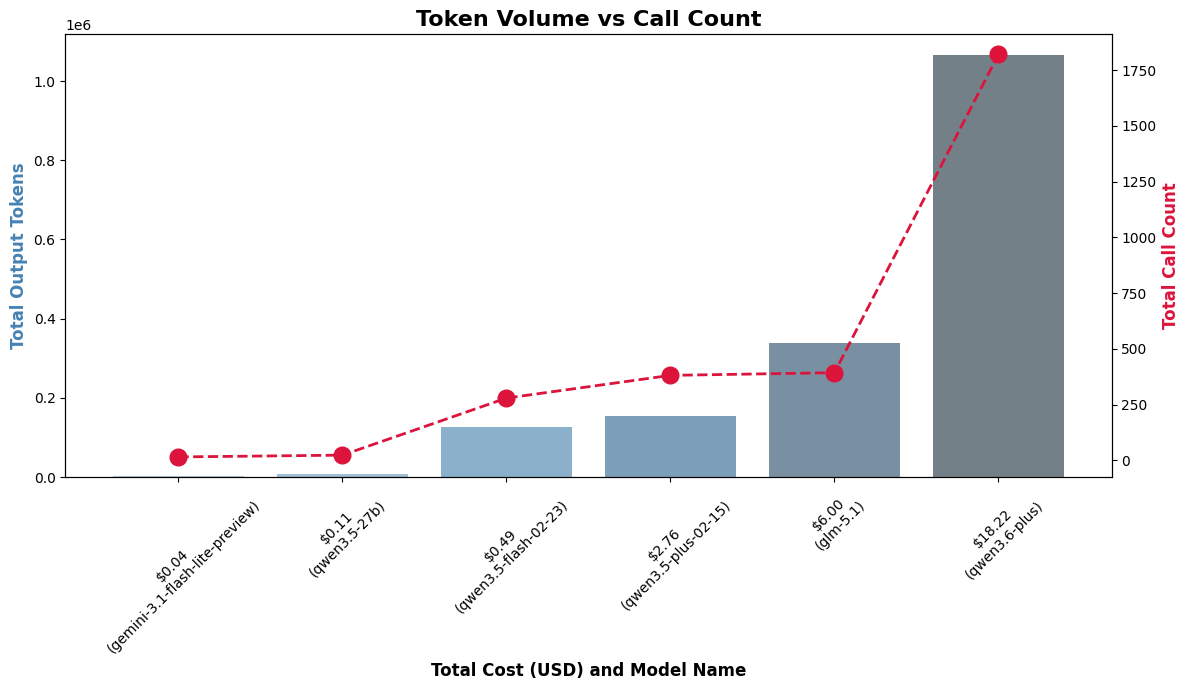

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ... (assuming 'data' is defined)
df = pd.DataFrame.from_dict(data, orient='index').reset_index()
df.rename(columns={'index': 'model'}, inplace=True)
df['model_short'] = df['model'].str.split('/').str[-1]
df = df.sort_values('total_cost').reset_index(drop=True)
df['x_label'] = df.apply(lambda x: f"${x['total_cost']:.2f}\n({x['model_short']})", axis=1)

fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(x='x_label', y='output_tokens', data=df, palette='Blues_d', alpha=0.7, ax=ax1)

# Secondary axis
ax2 = ax1.twinx()
ax2.plot(df['x_label'], df['call_count'], color='crimson', marker='o', markersize=12, linestyle='--', linewidth=2)

# Labels and Title
ax1.set_xlabel('Total Cost (USD) and Model Name', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Output Tokens', fontsize=12, color='steelblue', fontweight='bold')
ax2.set_ylabel('Total Call Count', fontsize=12, color='crimson', fontweight='bold')
plt.title('Token Volume vs Call Count', fontsize=16, fontweight='bold')

# --- ADDED: Rotate x-axis labels ---
ax1.tick_params(axis='x', labelrotation=45)
# Alternatively, for finer control over alignment:
# plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Extract Assessments - each assessment is separate, NOT averaged
assessments_data = []
for trace in tqdm(traces, desc="Fetching assessments"):
    trace_id = trace.info.trace_id
    try:
        assessments = trace.search_assessments(all=True)
        if assessments:
            for assessment in assessments:
                feedback_value = assessment.feedback.value if assessment.feedback else None
                assessments_data.append({
                    'trace_id': trace_id,
                    'assessment_name': assessment.name,
                    'assessment_id': assessment.assessment_id,
                    'feedback_value': feedback_value,
                })
    except Exception as e:
        pass

assessments_df = pd.DataFrame(assessments_data)
print(f"Total assessments: {len(assessments_df)}")
if len(assessments_df) > 0:
    print(f"Assessment types: {assessments_df['assessment_name'].unique()}")
    print(f"Unique traces with assessments: {assessments_df['trace_id'].nunique()}")
assessments_df.head()

Fetching assessments: 100%|██████████| 70/70 [00:00<00:00, 180234.06it/s]

Total assessments: 210
Assessment types: ['HumanJudgement' 'VideoRecall' 'AnswerCorrectnessPoint']
Unique traces with assessments: 70


,trace_id,assessment_name,assessment_id,feedback_value
0,tr-2b35f46018dd98383e97c207cea057a2,HumanJudgement,a-7ab095d5421d4b46a71c1c50bd45adfe,0.90
1,tr-2b35f46018dd98383e97c207cea057a2,VideoRecall,a-d568fe440793480da05d6cc20b16211b,0.33
2,tr-2b35f46018dd98383e97c207cea057a2,AnswerCorrectnessPoint,a-3e857746c1c34d85821704dd4c83a2cb,1.00
3,tr-c59695308af3dad1c0246b3d474fd588,HumanJudgement,a-776e7f5fc0b2434d94b17ecedca945e5,0.70
4,tr-c59695308af3dad1c0246b3d474fd588,VideoRecall,a-89cccc4cdbc24c759e633f877b656b97,1.00


In [ ]:
# Merge each INDIVIDUAL assessment with its trace's cost
# DO NOT average - each assessment row stays separate
cost_summary_df = pd.DataFrame(all_traces_summary)

if len(assessments_df) > 0:
    # Each assessment gets its trace's cost (not aggregated)
    merged_df = assessments_df.merge(
        cost_summary_df[['trace_id', 'total_input_tokens', 'total_output_tokens', 'total_cost']],
        on='trace_id',
        how='left'
    )
    
    # Add pass/fail per assessment (threshold >= 0.5)
    merged_df['passed'] = merged_df['feedback_value'] >= 0.5
    
    print(f"Total individual assessments: {len(merged_df)}")
    print(f"Average feedback value: {merged_df['feedback_value'].mean():.3f}")
    print(f"Pass rate (>=0.5): {merged_df['passed'].mean()*100:.1f}%")
    merged_df.head(10)
else:
    merged_df = pd.DataFrame()
    print('No assessments found')

Total individual assessments: 210
Average feedback value: 0.784
Pass rate (>=0.5): 85.7%


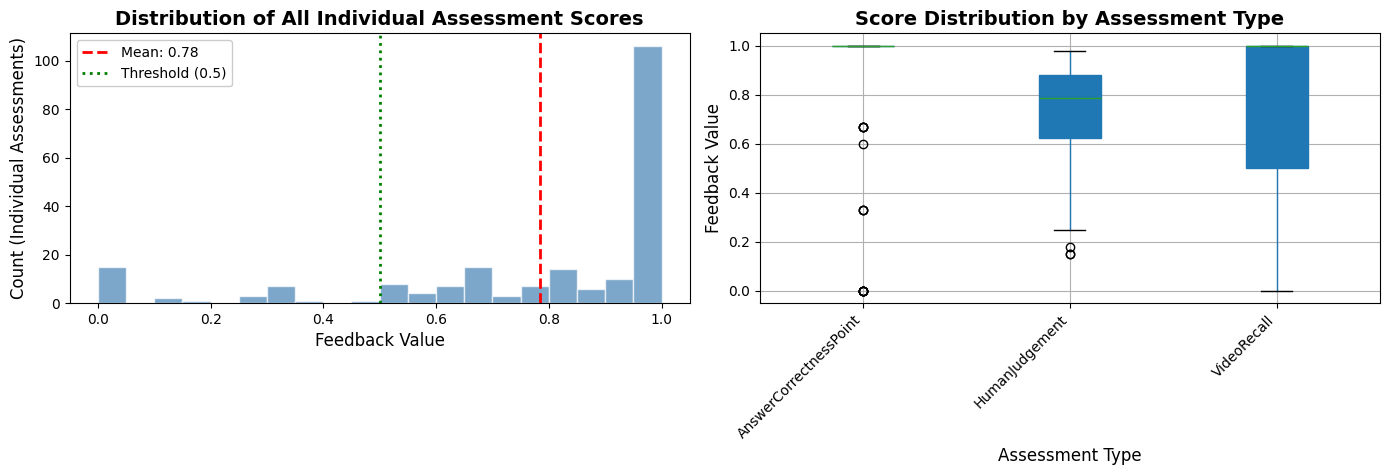

In [ ]:
# 1. Distribution of Individual Assessment Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram of all feedback values
ax1 = axes[0]
if len(merged_df) > 0:
    scores = merged_df['feedback_value'].dropna()
    ax1.hist(scores, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax1.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores.mean():.2f}')
    ax1.axvline(0.5, color='green', linestyle=':', linewidth=2, label='Threshold (0.5)')
    ax1.set_xlabel('Feedback Value', fontsize=12)
    ax1.set_ylabel('Count (Individual Assessments)', fontsize=12)
    ax1.set_title('Distribution of All Individual Assessment Scores', fontsize=14, fontweight='bold')
    legend = ax1.legend()
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(1)
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', transform=ax1.transAxes)

# Box plot by assessment type
ax2 = axes[1]
if len(merged_df) > 0 and 'assessment_name' in merged_df.columns:
    assessment_types = merged_df['assessment_name'].unique()
    if len(assessment_types) > 1:
        merged_df.boxplot(column='feedback_value', by='assessment_name', ax=ax2, patch_artist=True)
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
        ax2.set_xlabel('Assessment Type', fontsize=12)
        ax2.set_ylabel('Feedback Value', fontsize=12)
        ax2.set_title('Score Distribution by Assessment Type', fontsize=14, fontweight='bold')
        plt.suptitle('')
    else:
        ax2.text(0.5, 0.5, f'Single type: {assessment_types[0]}', ha='center', transform=ax2.transAxes, fontsize=12)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

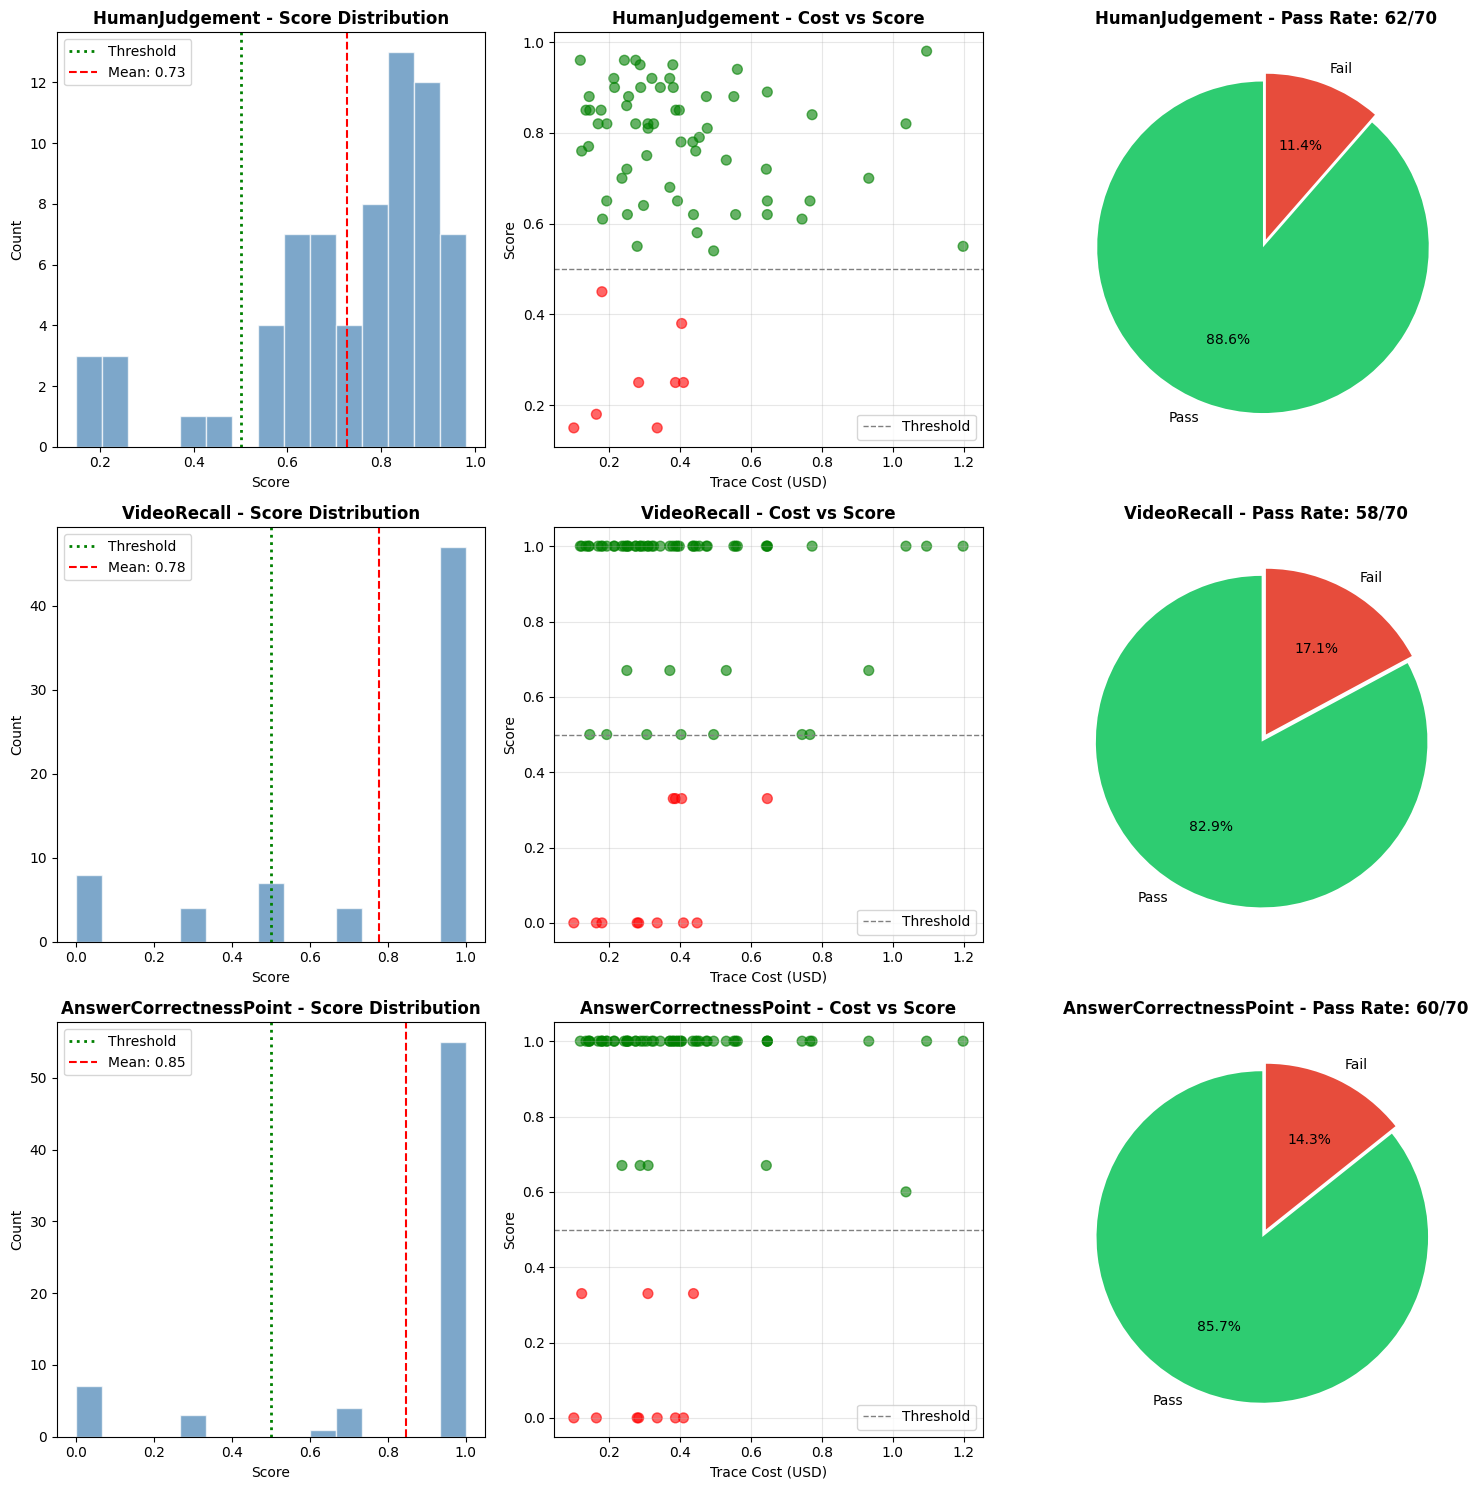

In [ ]:
# 2. Per-Assessment Type Analysis (Individual Scores)
if len(merged_df) > 0 and 'assessment_name' in merged_df.columns:
    assessment_types = merged_df['assessment_name'].unique()
    n_types = len(assessment_types)
    
    # Create subplots for each assessment type
    fig, axes = plt.subplots(n_types, 3, figsize=(15, 5*n_types))
    if n_types == 1:
        axes = axes.reshape(1, -1)
    
    for i, assessment_type in enumerate(assessment_types):
        type_df = merged_df[merged_df['assessment_name'] == assessment_type]
        
        # Plot 1: Score distribution for this type
        ax1 = axes[i, 0]
        ax1.hist(type_df['feedback_value'].dropna(), bins=15, color='steelblue', alpha=0.7, edgecolor='white')
        ax1.axvline(0.5, color='green', linestyle=':', linewidth=2, label='Threshold')
        ax1.axvline(type_df['feedback_value'].mean(), color='red', linestyle='--', label=f'Mean: {type_df["feedback_value"].mean():.2f}')
        ax1.set_xlabel('Score')
        ax1.set_ylabel('Count')
        ax1.set_title(f'{assessment_type} - Score Distribution', fontweight='bold')
        ax1.legend()
        
        # Plot 2: Cost vs Score for this assessment type
        ax2 = axes[i, 1]
        colors = type_df['passed'].map({True: 'green', False: 'red'})
        ax2.scatter(type_df['total_cost'], type_df['feedback_value'], c=colors, alpha=0.6, s=50)
        ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Threshold')
        ax2.set_xlabel('Trace Cost (USD)')
        ax2.set_ylabel('Score')
        ax2.set_title(f'{assessment_type} - Cost vs Score', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Pass/Fail pie chart for this type
        ax3 = axes[i, 2]
        pass_count = type_df['passed'].sum()
        fail_count = len(type_df) - pass_count
        ax3.pie([pass_count, fail_count], labels=['Pass', 'Fail'], autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0))
        ax3.set_title(f'{assessment_type} - Pass Rate: {pass_count}/{len(type_df)}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print('No assessment data available')

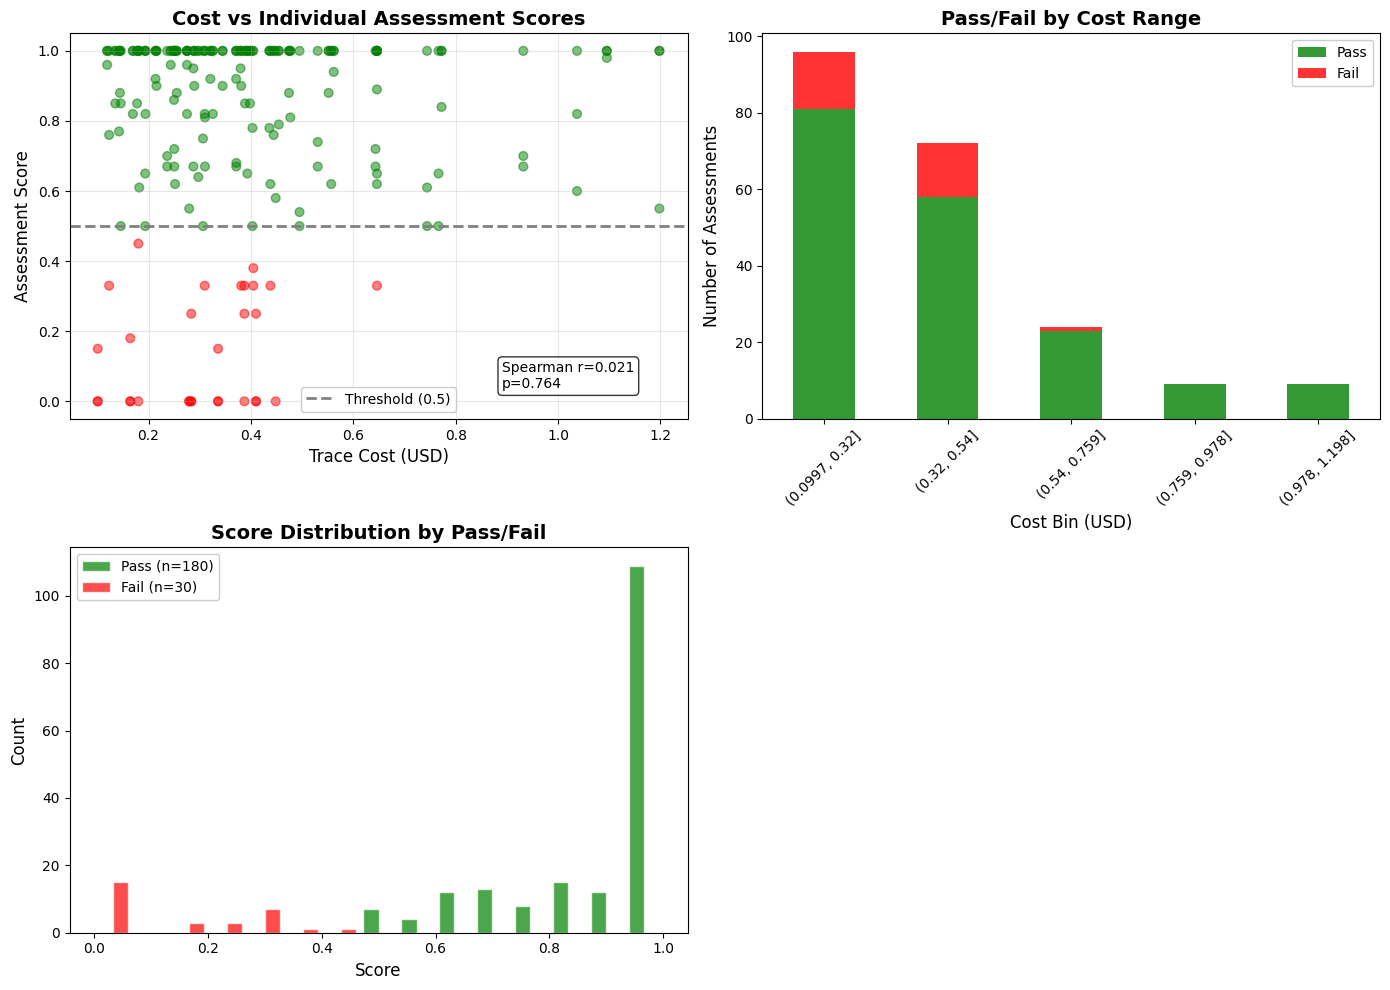


Summary: 0.021 correlation between cost and individual scores
Passing assessments avg cost: $0.4095
Failing assessments avg cost: $0.3040


In [ ]:
# 3. Cost vs Score - All Individual Assessments
# Changed to (2, 2) to accommodate 3 plots more naturally, or (3, 1) if you prefer a vertical stack
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if len(merged_df) > 0:
    # 1. Scatter: Cost vs Score
    # axes is now a 2D array: [0, 0], [0, 1], [1, 0], [1, 1]
    ax1 = axes[0, 0]
    colors = merged_df['passed'].map({True: 'green', False: 'red'})
    ax1.scatter(merged_df['total_cost'], merged_df['feedback_value'], c=colors, alpha=0.5, s=40)
    ax1.axhline(0.5, color='gray', linestyle='--', linewidth=2, label='Threshold (0.5)')
    ax1.set_xlabel('Trace Cost (USD)', fontsize=12)
    ax1.set_ylabel('Assessment Score', fontsize=12)
    ax1.set_title('Cost vs Individual Assessment Scores', fontsize=14, fontweight='bold')
    
    # White legend box
    leg1 = ax1.legend(facecolor='white', framealpha=1)
    ax1.grid(True, alpha=0.3)
    
    # Correlation Calculation
    from scipy.stats import spearmanr
    corr, p_val = spearmanr(merged_df['total_cost'], merged_df['feedback_value'])
    ax1.text(0.70, 0.15, f'Spearman r={corr:.3f}\np={p_val:.3f}', 
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 2. Pass/Fail by cost range
    ax2 = axes[0, 1]
    # Ensure cost_bins is defined (e.g., pd.cut(merged_df['total_cost'], bins=5))
    pass_by_cost = merged_df.groupby(cost_bins, observed=False)['passed'].agg(['sum', 'count']).reset_index()
    pass_by_cost['fail'] = pass_by_cost['count'] - pass_by_cost['sum']
    
    pass_by_cost.set_index(pass_by_cost.iloc[:,0].astype(str))[['sum', 'fail']].plot(
        kind='bar', stacked=True, ax=ax2, color=['green', 'red'], alpha=0.8)
    ax2.set_xlabel('Cost Bin (USD)', fontsize=12)
    ax2.set_ylabel('Number of Assessments', fontsize=12)
    ax2.set_title('Pass/Fail by Cost Range', fontsize=14, fontweight='bold')
    ax2.legend(['Pass', 'Fail'], facecolor='white', framealpha=1)
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. Score histogram by pass/fail
    ax3 = axes[1, 0]
    passing = merged_df[merged_df['passed']]
    failing = merged_df[~merged_df['passed']]
    ax3.hist([passing['feedback_value'], failing['feedback_value']], bins=15, alpha=0.7,
             label=[f'Pass (n={len(passing)})', f'Fail (n={len(failing)})'],
             color=['green', 'red'], edgecolor='white')
    ax3.legend(facecolor='white', framealpha=1)
    ax3.set_xlabel('Score', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.set_title('Score Distribution by Pass/Fail', fontsize=14, fontweight='bold')

    # Remove the empty 4th subplot
    fig.delaxes(axes[1, 1])

else:
    # Handle empty dataframe case for all axes
    for ax in axes.flat:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

if len(merged_df) > 0:
    print(f"\nSummary: {corr:.3f} correlation between cost and individual scores")
    print(f"Passing assessments avg cost: ${passing['total_cost'].mean():.4f}")
    print(f"Failing assessments avg cost: ${failing['total_cost'].mean():.4f}")

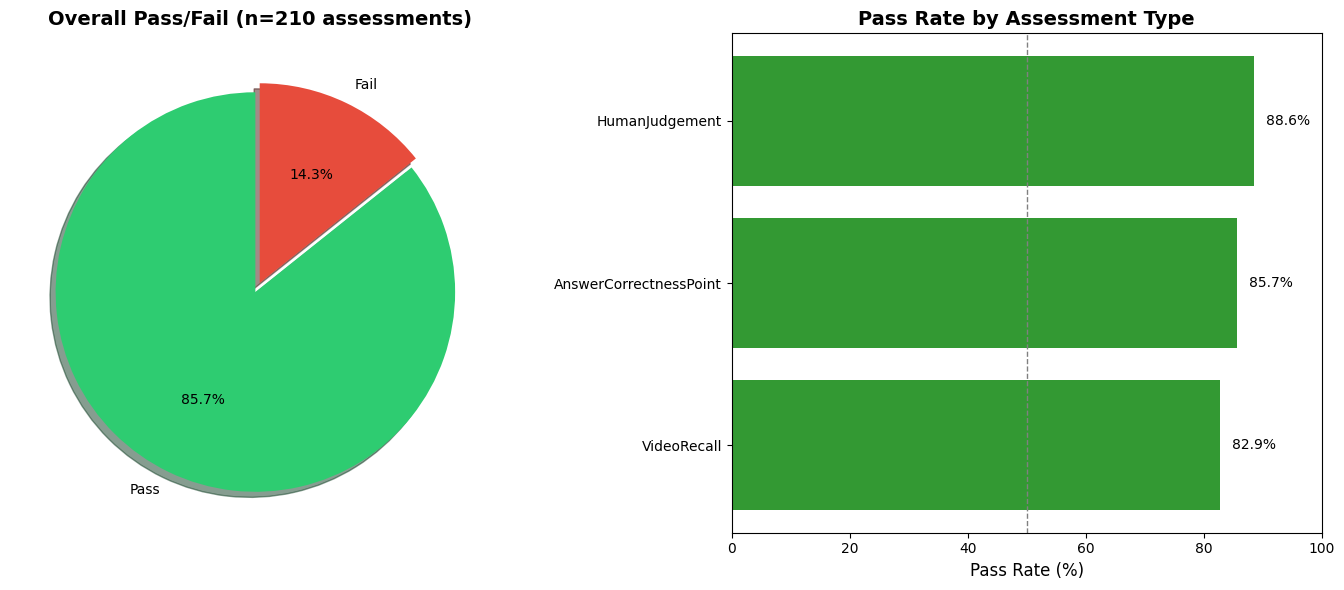

In [ ]:
# 4. Pass/Fail Analysis - Individual Assessments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(merged_df) > 0:
    # Overall pass/fail pie
    ax1 = axes[0]
    pass_count = merged_df['passed'].sum()
    fail_count = len(merged_df) - pass_count
    ax1.pie([pass_count, fail_count], labels=['Pass', 'Fail'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0), shadow=True)
    ax1.set_title(f'Overall Pass/Fail (n={len(merged_df)} assessments)', fontsize=14, fontweight='bold')
    
    # Pass rate by assessment type
    ax2 = axes[1]
    if 'assessment_name' in merged_df.columns:
        pass_rates = merged_df.groupby('assessment_name')['passed'].mean() * 100
        pass_rates = pass_rates.sort_values(ascending=True)
        colors = ['green' if r >= 70 else 'orange' if r >= 50 else 'red' for r in pass_rates.values]
        ax2.barh(pass_rates.index, pass_rates.values, color=colors, alpha=0.8)
        ax2.set_xlabel('Pass Rate (%)', fontsize=12)
        ax2.set_title('Pass Rate by Assessment Type', fontsize=14, fontweight='bold')
        ax2.set_xlim(0, 100)
        ax2.axvline(50, color='gray', linestyle='--', linewidth=1)
        for i, (name, rate) in enumerate(pass_rates.items()):
            ax2.text(rate + 2, i, f'{rate:.1f}%', va='center', fontsize=10)
    else:
        ax2.text(0.5, 0.5, 'No type data', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

In [ ]:
# 5. Summary Table - Per Assessment Type
if len(merged_df) > 0 and 'assessment_name' in merged_df.columns:
    summary = merged_df.groupby('assessment_name').agg({
        'feedback_value': ['count', 'mean', 'std', 'min', 'max'],
        'passed': ['sum', 'mean'],
        'total_cost': ['mean', 'min', 'max']
    }).reset_index()
    
    summary.columns = ['Assessment', 'Count', 'Avg Score', 'Std', 'Min Score', 'Max Score',
                       'Pass Count', 'Pass Rate', 'Avg Cost', 'Min Cost', 'Max Cost']
    summary['Pass Rate'] = summary['Pass Rate'] * 100
    
    print("\n" + "="*80)
    print("         ASSESSMENT SUMMARY (Individual Scores, NOT averaged per trace)")
    print("="*80)
    display(summary.round(3))
    
    print(f"\nTotal Assessments: {len(merged_df)}")
    print(f"Unique Traces: {merged_df['trace_id'].nunique()}")
    print(f"Overall Pass Rate: {merged_df['passed'].mean()*100:.1f}%")
else:
    print('No assessment data')


         ASSESSMENT SUMMARY (Individual Scores, NOT averaged per trace)


,Assessment,Count,Avg Score,Std,Min Score,Max Score,Pass Count,Pass Rate,Avg Cost,Min Cost,Max Cost
0,AnswerCorrectnessPoint,70,0.847,0.325,0.00,1.00,60,85.714,0.394,0.101,1.198
1,HumanJudgement,70,0.726,0.208,0.15,0.98,62,88.571,0.394,0.101,1.198
2,VideoRecall,70,0.779,0.352,0.00,1.00,58,82.857,0.394,0.101,1.198



Total Assessments: 210
Unique Traces: 70
Overall Pass Rate: 85.7%


In [ ]:
# ============================================================
# TOOL USAGE ANALYSIS
# ============================================================
print("\nExtracting tool usage from traces...")


Extracting tool usage from traces...


In [ ]:
# Extract all tool calls from spans
tool_calls_data = []

for trace in tqdm(traces, desc="Extracting tool calls"):
    trace_id = trace.info.trace_id
    for span in trace.data.spans:
        attrs = span.attributes or {}
        
        # Check for TOOL span type
        if span.span_type == 'TOOL' or 'tool' in span.name.lower():
            tool_name = attrs.get('tool.name', span.name)
            if tool_name:
                # Get tool category (prefix)
                if '.' in tool_name:
                    category = tool_name.split('.')[0]
                else:
                    category = 'agent'
                
                tool_calls_data.append({
                    'trace_id': trace_id,
                    'tool_name': tool_name,
                    'tool_category': category,
                    'span_name': span.name,
                    'span_type': str(span.span_type)
                })

tools_df = pd.DataFrame(tool_calls_data)
print(f"Total tool calls: {len(tools_df)}")
if len(tools_df) > 0:
    print(f"Unique tools: {tools_df['tool_name'].nunique()}")
    print(f"Categories: {tools_df['tool_category'].unique()}")
tools_df.head()

Extracting tool calls:  13%|█▎        | 9/70 [00:00<00:00, 83.78it/s]

Extracting tool calls: 100%|██████████| 70/70 [00:01<00:00, 67.23it/s]

Total tool calls: 2571
Unique tools: 26
Categories: ['agent']


,trace_id,tool_name,tool_category,span_name,span_type
0,tr-2b35f46018dd98383e97c207cea057a2,get_member_information,agent,get_member_information,TOOL
1,tr-2b35f46018dd98383e97c207cea057a2,delegate_task_to_member,agent,delegate_task_to_member,TOOL
2,tr-2b35f46018dd98383e97c207cea057a2,get_available_worker_tools,agent,get_available_worker_tools,TOOL
3,tr-2b35f46018dd98383e97c207cea057a2,get_available_models,agent,get_available_models,TOOL
4,tr-2b35f46018dd98383e97c207cea057a2,spawn_and_run_worker,agent,spawn_and_run_worker,TOOL


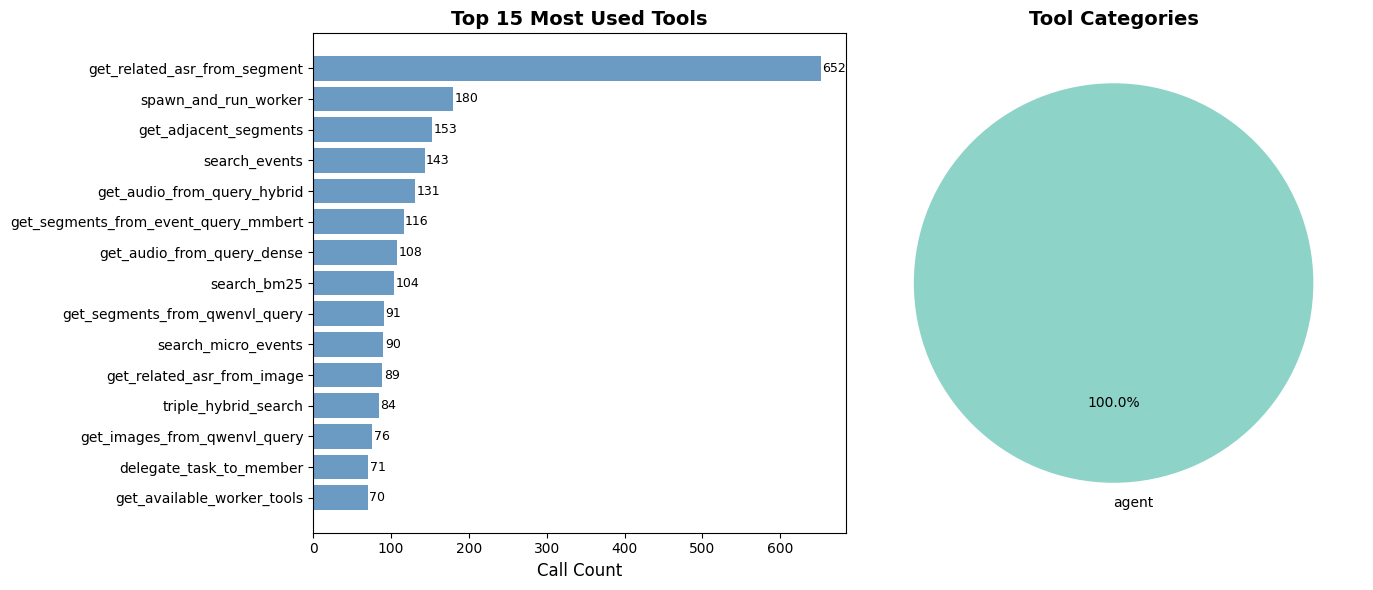

In [ ]:
# Tool Call Frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(tools_df) > 0:
    # Top 15 most used tools
    ax1 = axes[0]
    tool_counts = tools_df['tool_name'].value_counts().head(15)
    ax1.barh(range(len(tool_counts)), tool_counts.values, color='steelblue', alpha=0.8)
    ax1.set_yticks(range(len(tool_counts)))
    ax1.set_yticklabels(tool_counts.index, fontsize=10)
    ax1.set_xlabel('Call Count', fontsize=12)
    ax1.set_title('Top 15 Most Used Tools', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    for i, v in enumerate(tool_counts.values):
        ax1.text(v + 2, i, str(v), va='center', fontsize=9)
    
    # Tool category breakdown
    ax2 = axes[1]
    category_counts = tools_df['tool_category'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
    ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax2.set_title('Tool Categories', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No tool data', ha='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'No tool data', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

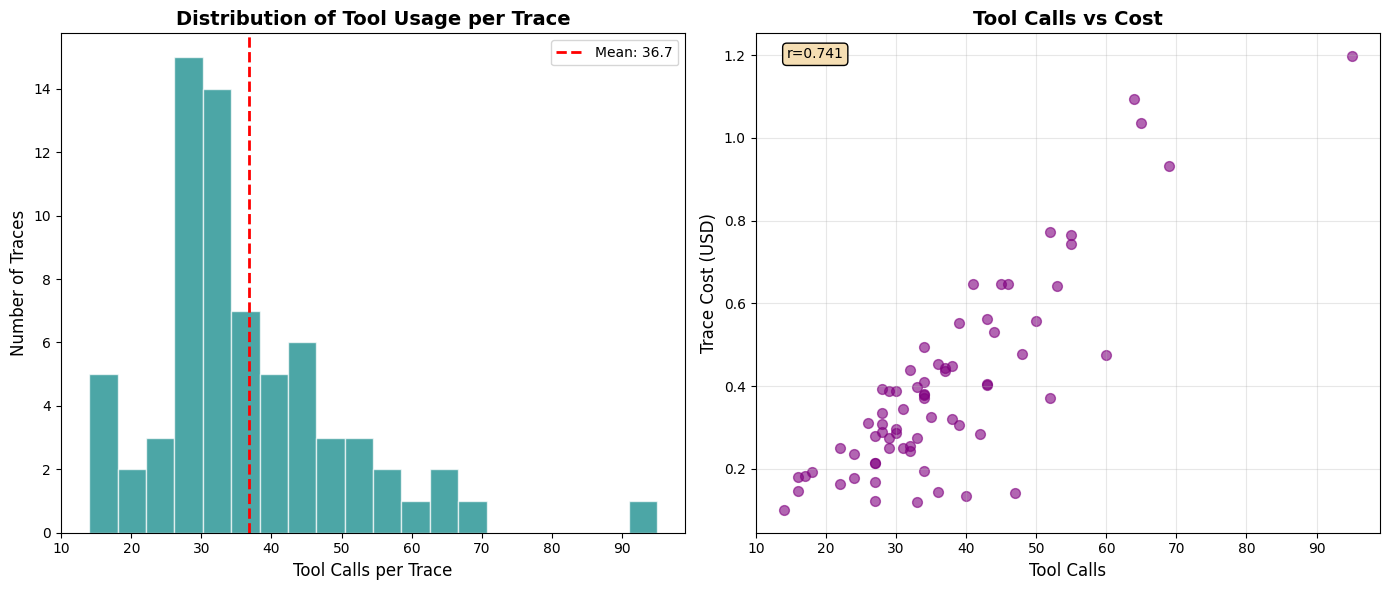


Correlation: More tools → higher cost (r=0.741)


In [ ]:
# Tool Usage per Trace
if len(tools_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Distribution of tool calls per trace
    ax1 = axes[0]
    tools_per_trace = tools_df.groupby('trace_id').size()
    ax1.hist(tools_per_trace, bins=20, color='teal', alpha=0.7, edgecolor='white')
    ax1.axvline(tools_per_trace.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {tools_per_trace.mean():.1f}')
    ax1.set_xlabel('Tool Calls per Trace', fontsize=12)
    ax1.set_ylabel('Number of Traces', fontsize=12)
    ax1.set_title('Distribution of Tool Usage per Trace', fontsize=14, fontweight='bold')
    ax1.legend()
    
    # Merge tool count with cost
    ax2 = axes[1]
    trace_tool_count = tools_df.groupby('trace_id').size().reset_index(name='tool_count')
    trace_cost = pd.DataFrame(all_traces_summary)[['trace_id', 'total_cost']]
    tool_cost_df = trace_tool_count.merge(trace_cost, on='trace_id')
    
    ax2.scatter(tool_cost_df['tool_count'], tool_cost_df['total_cost'], alpha=0.6, c='purple', s=50)
    ax2.set_xlabel('Tool Calls', fontsize=12)
    ax2.set_ylabel('Trace Cost (USD)', fontsize=12)
    ax2.set_title('Tool Calls vs Cost', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    from scipy.stats import spearmanr
    corr, p = spearmanr(tool_cost_df['tool_count'], tool_cost_df['total_cost'])
    ax2.text(0.05, 0.95, f'r={corr:.3f}', transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat'))
    
    plt.tight_layout()
    plt.show()
    print(f"\nCorrelation: More tools → higher cost (r={corr:.3f})")

/tmp/ipykernel_58194/1200543085.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pass_by_tools = tool_quality_df.groupby(tool_bins)['passed'].mean() * 100


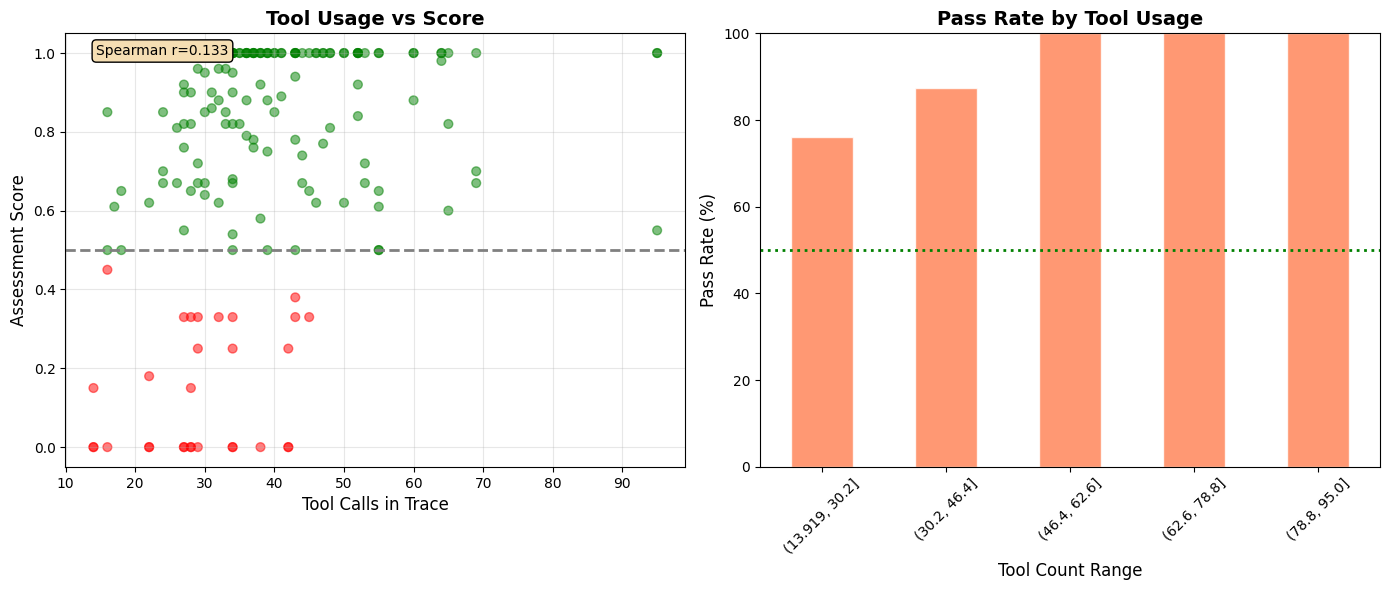


Correlation: Tool count vs Score = 0.133
More tools → better scores)


In [ ]:
# Tool Usage vs Assessment Quality
if len(tools_df) > 0 and len(merged_df) > 0:
    # Count tools per trace
    trace_tool_count = tools_df.groupby('trace_id').size().reset_index(name='tool_count')
    
    # Merge with individual assessments (each assessment gets its trace's tool count)
    tool_quality_df = merged_df.merge(trace_tool_count, on='trace_id', how='left')
    tool_quality_df['tool_count'] = tool_quality_df['tool_count'].fillna(0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Tool count vs Score
    ax1 = axes[0]
    colors = tool_quality_df['passed'].map({True: 'green', False: 'red'})
    ax1.scatter(tool_quality_df['tool_count'], tool_quality_df['feedback_value'],
                c=colors, alpha=0.5, s=40)
    ax1.axhline(0.5, color='gray', linestyle='--', linewidth=2)
    ax1.set_xlabel('Tool Calls in Trace', fontsize=12)
    ax1.set_ylabel('Assessment Score', fontsize=12)
    ax1.set_title('Tool Usage vs Score', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    from scipy.stats import spearmanr
    corr, p = spearmanr(tool_quality_df['tool_count'], tool_quality_df['feedback_value'])
    ax1.text(0.05, 0.95, f'Spearman r={corr:.3f}', transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # Pass rate by tool count bins
    ax2 = axes[1]
    tool_bins = pd.cut(tool_quality_df['tool_count'], bins=5)
    pass_by_tools = tool_quality_df.groupby(tool_bins)['passed'].mean() * 100
    pass_by_tools.plot(kind='bar', ax=ax2, color='coral', alpha=0.8, edgecolor='white')
    ax2.axhline(50, color='green', linestyle=':', linewidth=2)
    ax2.set_xlabel('Tool Count Range', fontsize=12)
    ax2.set_ylabel('Pass Rate (%)', fontsize=12)
    ax2.set_title('Pass Rate by Tool Usage', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    print(f"\nCorrelation: Tool count vs Score = {corr:.3f}")
    print(f"{'More tools → better scores' if corr > 0.1 else 'No clear relationship' if corr < 0.1 else 'More tools → worse scores'})")

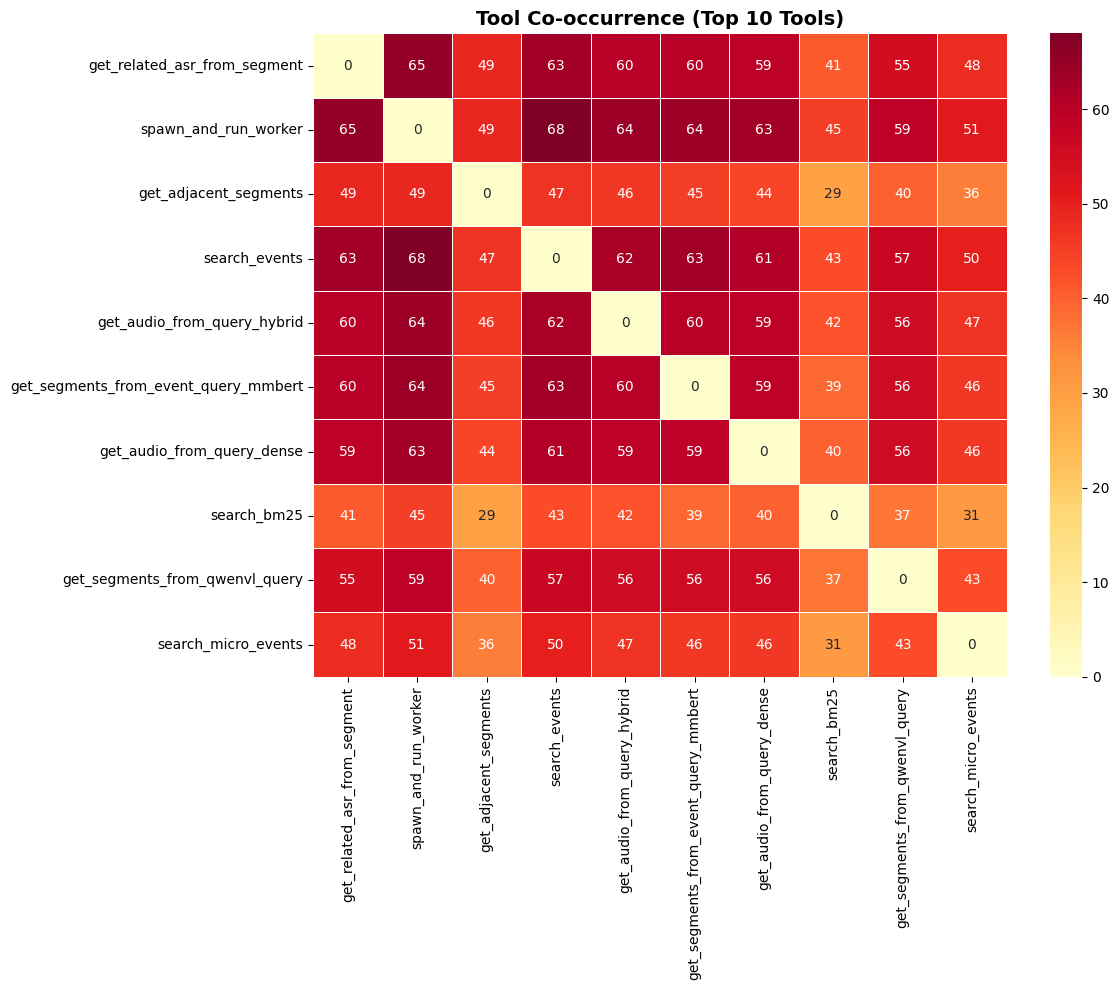

In [ ]:
# Tool Co-occurrence - Which tools are used together in same trace
if len(tools_df) > 0:
    from collections import Counter
    
    # Get top 10 tools
    top_tools = tools_df['tool_name'].value_counts().head(10).index.tolist()
    
    # Build co-occurrence matrix
    cooccur = Counter()
    for trace_id in tools_df['trace_id'].unique():
        trace_tools = set(tools_df[tools_df['trace_id'] == trace_id]['tool_name'].unique())
        trace_tools = [t for t in trace_tools if t in top_tools]
        for i, t1 in enumerate(trace_tools):
            for t2 in trace_tools[i+1:]:
                cooccur[(t1, t2)] += 1
                cooccur[(t2, t1)] += 1
    
    # Create matrix
    matrix = pd.DataFrame(0, index=top_tools, columns=top_tools)
    for (t1, t2), count in cooccur.items():
        if t1 in matrix.index and t2 in matrix.columns:
            matrix.loc[t1, t2] = count
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Tool Co-occurrence (Top 10 Tools)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No tool data')

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("         COMPLETE ANALYSIS SUMMARY")
print("="*70)

print(f"\n📊 TRACES")
print(f"   Total: {len(all_traces_summary)}")
print(f"   Total Cost: ${sum(t['total_cost'] for t in all_traces_summary):.4f}")

if len(merged_df) > 0:
    print(f"\n🎯 ASSESSMENTS (Individual, NOT averaged)")
    print(f"   Total: {len(merged_df)}")
    print(f"   Pass Rate: {merged_df['passed'].mean()*100:.1f}%")
    print(f"   Avg Score: {merged_df['feedback_value'].mean():.3f}")

if len(tools_df) > 0:
    print(f"\n🔧 TOOLS")
    print(f"   Total Calls: {len(tools_df)}")
    print(f"   Unique Tools: {tools_df['tool_name'].nunique()}")
    print(f"   Avg per Trace: {tools_df.groupby('trace_id').size().mean():.1f}")
    
print(f"\n" + "="*70)


         COMPLETE ANALYSIS SUMMARY

📊 TRACES
   Total: 70
   Total Cost: $27.6091

🎯 ASSESSMENTS (Individual, NOT averaged)
   Total: 210
   Pass Rate: 85.7%
   Avg Score: 0.784

🔧 TOOLS
   Total Calls: 2571
   Unique Tools: 26
   Avg per Trace: 36.7



In [ ]:
# Tool Sequence Analysis - Extract ordered tool call sequences per trace
from collections import Counter

tool_sequences = {}
for trace in tqdm(traces, desc='Extracting tool sequences'):
    trace_id = trace.info.trace_id
    sequence = []
    for span in trace.data.spans:
        attrs = span.attributes or {}
        if span.span_type == 'TOOL' or 'tool' in span.name.lower():
            tool_name = attrs.get('tool.name', span.name)
            if tool_name and tool_name not in ['get_member_information', 'get_available_worker_tools', 'get_available_models']:
                sequence.append(tool_name)
    if sequence:
        tool_sequences[trace_id] = sequence

print(f'Extracted sequences from {len(tool_sequences)} traces')
print(f'Example sequence: {list(tool_sequences.values())[0][:5]}...')

Extracting tool sequences: 100%|██████████| 70/70 [00:01<00:00, 67.63it/s]

Extracted sequences from 70 traces
Example sequence: ['delegate_task_to_member', 'spawn_and_run_worker', 'triple_hybrid_search', 'search_bm25', 'search_entities_semantic']...


In [ ]:
tool_sequences.keys()

dict_keys(['tr-2b35f46018dd98383e97c207cea057a2', 'tr-c59695308af3dad1c0246b3d474fd588', 'tr-26f3f4126a6ef4f29783ddd36c19bfe8', 'tr-2d26e251e7afb64d9a467bb4fc451fc4', 'tr-20c3a36333100acf40c031fe936d2368', 'tr-269e6c053edc3e73cb39986a8c841e61', 'tr-df52bcd29ec748db08e4a30bd83ef818', 'tr-a2aff3ca752f3608141ea018e66e59ea', 'tr-d20dbec3881e2c9df7ca5bd419d3c58f', 'tr-d9fe3e99932901aa0692866904d78437', 'tr-6b62c302513eb29d05765e31cea0a749', 'tr-c8bf332825c8aab3d7e34ed55baa767d', 'tr-54ed312bd8d56c564b556d7350c9a958', 'tr-6ee63845088e8d3223735ad2ee908fcc', 'tr-1a52f88bcda4e49aaa5b90ff458a9893', 'tr-da0b70daabe828faaffe8e8f593bce35', 'tr-6b185db5850c719c9ed36857f0ff159e', 'tr-1dff487ac1ca0134ac4624a03ce1f557', 'tr-5f4f2a5e0ade3fb3d2dafb815c892660', 'tr-2ae928658a9074b82f2532b7713a52f5', 'tr-102ac03e8e568186b1e7daa5775b78ea', 'tr-70af9abcca08d37daa4bd02a5af9921b', 'tr-73def14b8f94d870b14dfaa5cbc62bdc', 'tr-e841568223c3eaba29e716b9a6e78381', 'tr-f19744a9006b6d26072fb16694ba11ac', 'tr-a29aa3b4dc

In [ ]:
tool_sequences["tr-2b35f46018dd98383e97c207cea057a2"]

['delegate_task_to_member',
 'spawn_and_run_worker',
 'triple_hybrid_search',
 'search_bm25',
 'search_entities_semantic',
 'get_segments_from_event_query_mmbert',
 'get_video_metadata',
 'get_video_timeline',
 'get_video_timeline',
 'get_video_metadata',
 'spawn_and_run_worker',
 'get_images_from_qwenvl_query',
 'get_images_from_qwenvl_query',
 'get_images_from_caption_query_mmbert',
 'get_segments_from_qwenvl_query',
 'get_segments_from_event_query_mmbert',
 'search_micro_events',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'spawn_and_run_worker',
 'get_audio_from_query_hybrid',
 'get_audio_from_query_dense',
 'get_audio_from_query_hybrid',
 'get_audio_from_query_dense',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'get_related_asr_from_segment',
 'search_events']

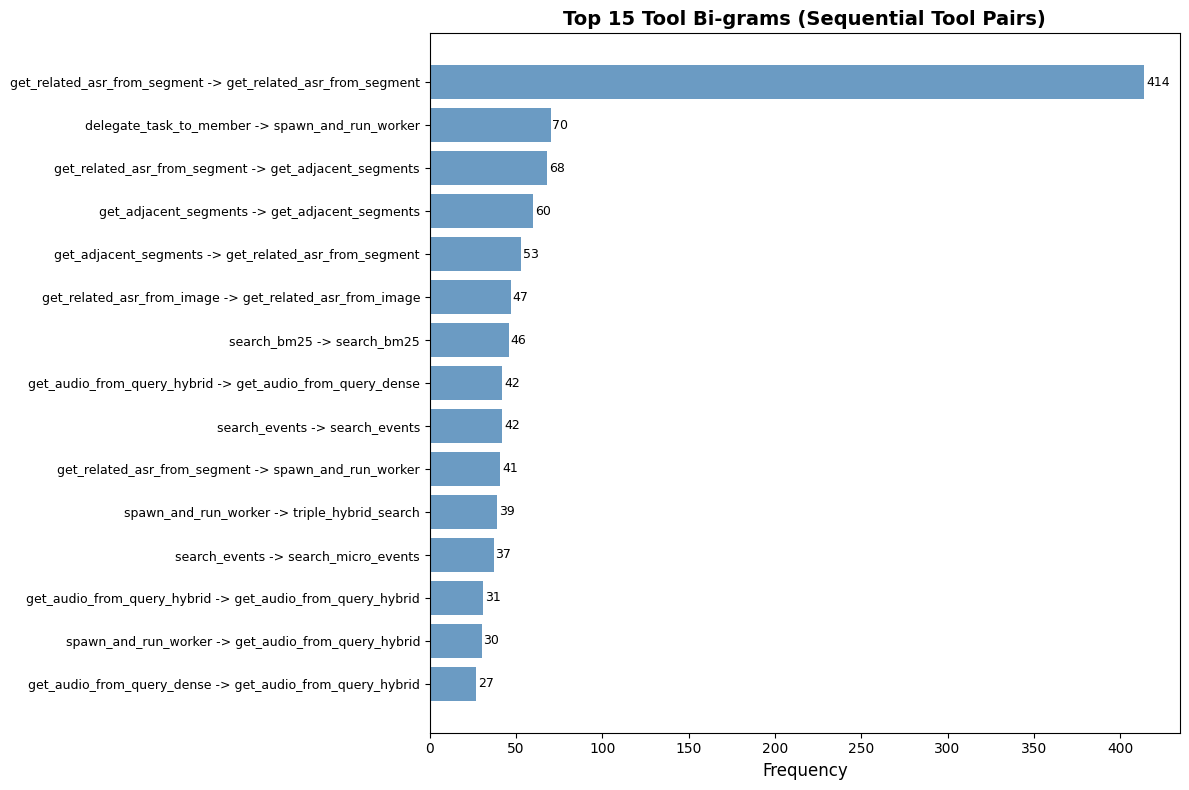


Total unique bi-grams: 254
Most common workflow: ('get_related_asr_from_segment', 'get_related_asr_from_segment') -> 414 (414 times)


In [ ]:
# Bi-gram Analysis - Most common tool pairs
bigrams = Counter()
for trace_id, seq in tool_sequences.items():
    for i in range(len(seq) - 1):
        bigram = (seq[i], seq[i+1])
        bigrams[bigram] += 1

top_bigrams = bigrams.most_common(15)

fig, ax = plt.subplots(figsize=(12, 8))
labels = [f'{b[0]} -> {b[1]}' for b, c in top_bigrams]
counts = [c for b, c in top_bigrams]

ax.barh(range(len(top_bigrams)), counts, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_bigrams)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 15 Tool Bi-grams (Sequential Tool Pairs)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (bigram, count) in enumerate(top_bigrams):
    ax.text(count + 1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nTotal unique bi-grams: {len(bigrams)}')
print(f'Most common workflow: {top_bigrams[0][0]} -> {top_bigrams[0][1]} ({top_bigrams[0][1]} times)')

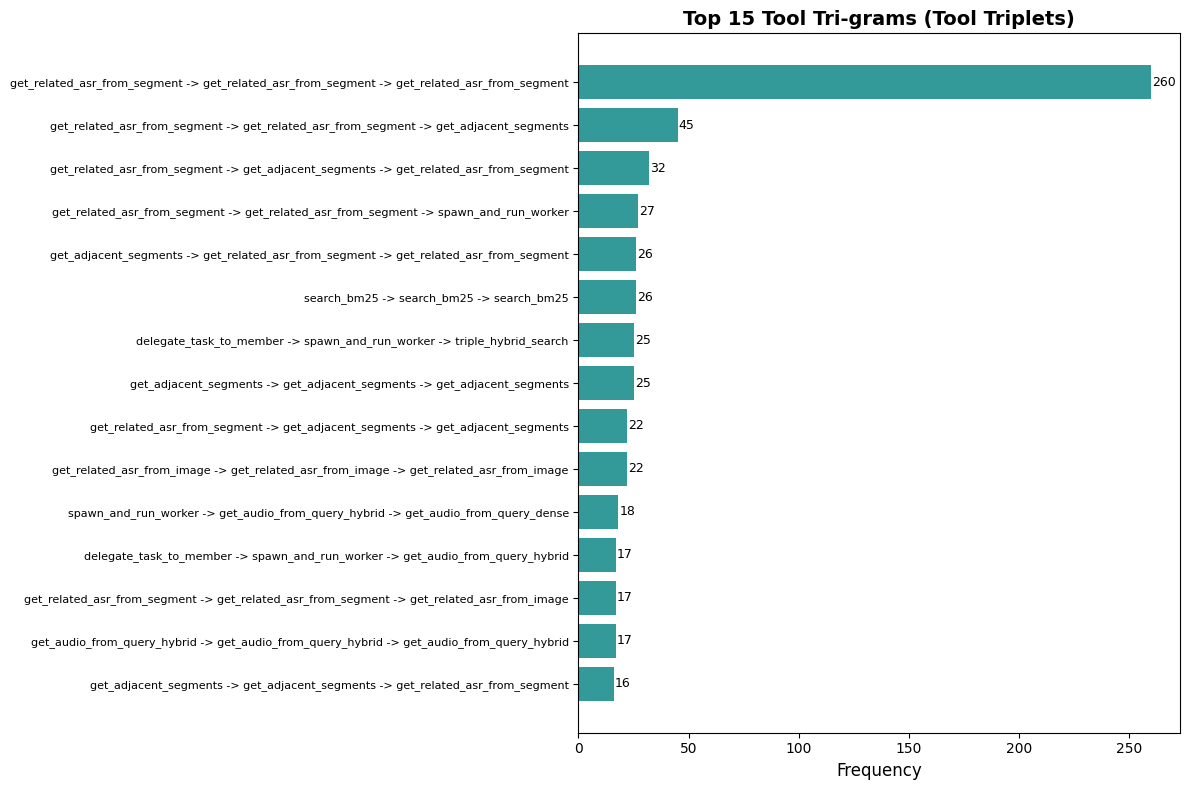


Total unique tri-grams: 764


In [ ]:
# Tri-gram Analysis - Most common tool triplets
trigrams = Counter()
for trace_id, seq in tool_sequences.items():
    for i in range(len(seq) - 2):
        trigram = (seq[i], seq[i+1], seq[i+2])
        trigrams[trigram] += 1

top_trigrams = trigrams.most_common(15)

fig, ax = plt.subplots(figsize=(12, 8))
labels = [f'{t[0]} -> {t[1]} -> {t[2]}' for t, c in top_trigrams]
counts = [c for t, c in top_trigrams]

ax.barh(range(len(top_trigrams)), counts, color='teal', alpha=0.8)
ax.set_yticks(range(len(top_trigrams)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 15 Tool Tri-grams (Tool Triplets)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (trigram, count) in enumerate(top_trigrams):
    ax.text(count + 0.5, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nTotal unique tri-grams: {len(trigrams)}')

TypeError: tuple indices must be integers or slices, not str

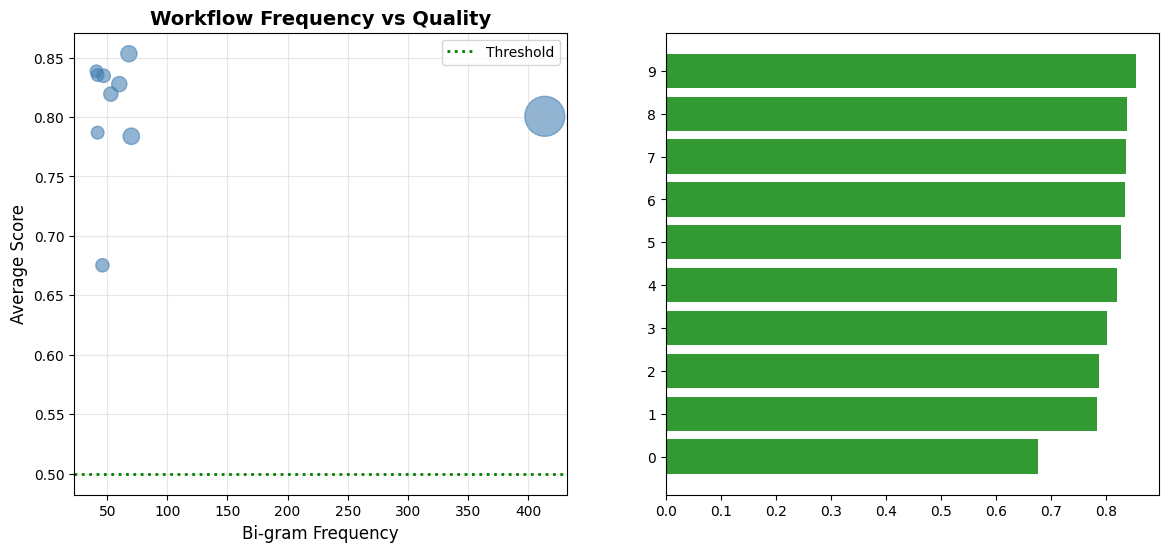

In [ ]:
# N-gram vs Quality - Do certain workflows lead to better scores?
if len(merged_df) > 0 and len(tool_sequences) > 0:
    trace_avg_scores = merged_df.groupby('trace_id')['feedback_value'].mean().reset_index()
    trace_avg_scores.columns = ['trace_id', 'avg_trace_score']
    
    bigram_quality = []
    for bigram, freq in top_bigrams[:10]:
        traces_with_bigram = [tid for tid, seq in tool_sequences.items()
                              if any(seq[i:i+2] == list(bigram) for i in range(len(seq)-1))]
        if traces_with_bigram:
            avg_score = trace_avg_scores[trace_avg_scores['trace_id'].isin(traces_with_bigram)]['avg_trace_score'].mean()
            bigram_str = f'{bigram[0]} -> {bigram[1]}'
            bigram_quality.append({'bigram': bigram_str, 'freq': freq, 'avg_score': avg_score})
    
    bigram_quality_df = pd.DataFrame(bigram_quality)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1 = axes[0]
    ax1.scatter(bigram_quality_df['freq'], bigram_quality_df['avg_score'], s=bigram_quality_df['freq']*2, alpha=0.6, c='steelblue')
    ax1.set_xlabel('Bi-gram Frequency', fontsize=12)
    ax1.set_ylabel('Average Score', fontsize=12)
    ax1.set_title('Workflow Frequency vs Quality', fontsize=14, fontweight='bold')
    ax1.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    sorted_quality = bigram_quality_df.sort_values('avg_score', ascending=True)
    colors = ['green' if s >= 0.5 else 'red' for s in sorted_quality['avg_score']]
    ax2.barh(range(len(sorted_quality)), sorted_quality['avg_score'], color=colors, alpha=0.8)
    ax2.set_yticks(range(len(sorted_quality)))
    ax2.set_yticklabels([row['bigram'][:30] for row in sorted_quality.itertuples()], fontsize=9)
    ax2.set_xlabel('Average Score', fontsize=12)
    ax2.set_title('Top Workflows Ranked by Quality', fontsize=14, fontweight='bold')
    ax2.axvline(0.5, color='gray', linestyle='--', linewidth=2)
    ax2.set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    print('\nWorkflow Quality Summary:')
    display(bigram_quality_df.round(3))

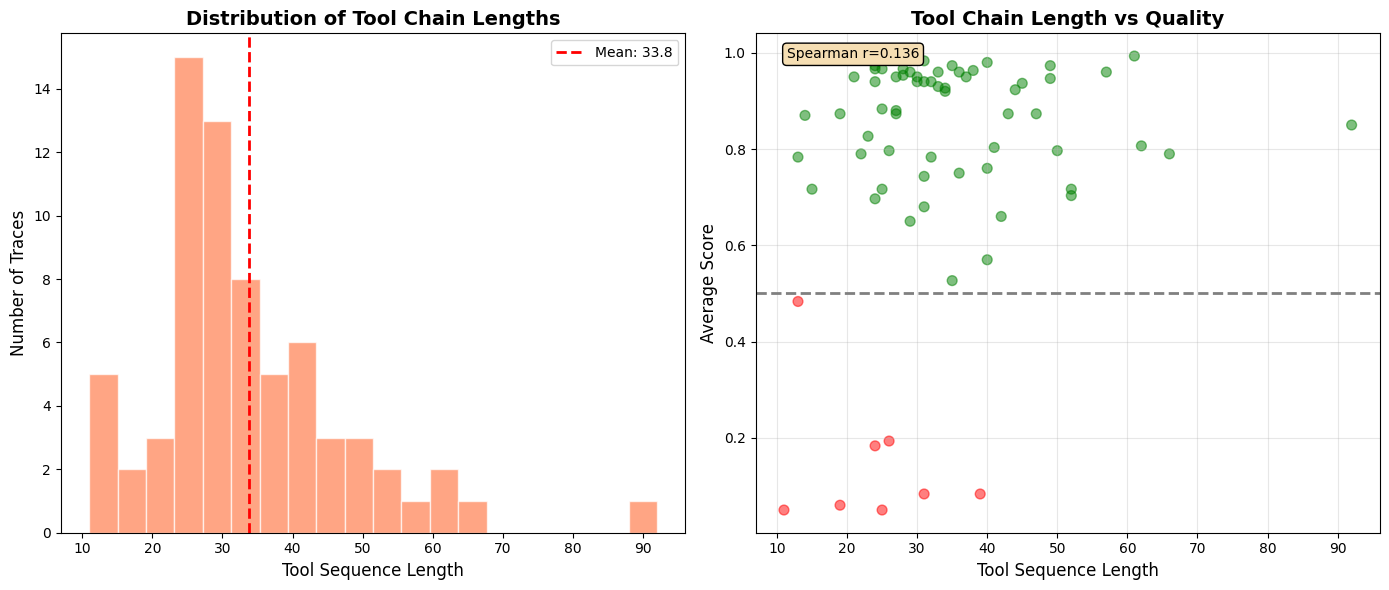


Correlation: Longer chains -> better scores (r=0.136)


In [ ]:
# Sequence Length vs Quality
if len(merged_df) > 0 and len(tool_sequences) > 0:
    seq_lengths = {tid: len(seq) for tid, seq in tool_sequences.items()}
    seq_df = pd.DataFrame(list(seq_lengths.items()), columns=['trace_id', 'seq_length'])
    
    trace_avg_scores = merged_df.groupby('trace_id')['feedback_value'].mean().reset_index()
    trace_avg_scores.columns = ['trace_id', 'avg_score']
    seq_quality = seq_df.merge(trace_avg_scores, on='trace_id')
    seq_quality['passed'] = seq_quality['avg_score'] >= 0.5
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1 = axes[0]
    ax1.hist(seq_quality['seq_length'], bins=20, color='coral', alpha=0.7, edgecolor='white')
    ax1.axvline(seq_quality['seq_length'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {seq_quality["seq_length"].mean():.1f}')
    ax1.set_xlabel('Tool Sequence Length', fontsize=12)
    ax1.set_ylabel('Number of Traces', fontsize=12)
    ax1.set_title('Distribution of Tool Chain Lengths', fontsize=14, fontweight='bold')
    ax1.legend()
    
    ax2 = axes[1]
    colors = seq_quality['passed'].map({True: 'green', False: 'red'})
    ax2.scatter(seq_quality['seq_length'], seq_quality['avg_score'], c=colors, alpha=0.5, s=50)
    ax2.axhline(0.5, color='gray', linestyle='--', linewidth=2)
    ax2.set_xlabel('Tool Sequence Length', fontsize=12)
    ax2.set_ylabel('Average Score', fontsize=12)
    ax2.set_title('Tool Chain Length vs Quality', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    from scipy.stats import spearmanr
    corr, p = spearmanr(seq_quality['seq_length'], seq_quality['avg_score'])
    ax2.text(0.05, 0.95, f'Spearman r={corr:.3f}', transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat'))
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nCorrelation: Longer chains -> {"better" if corr > 0 else "worse"} scores (r={corr:.3f})')

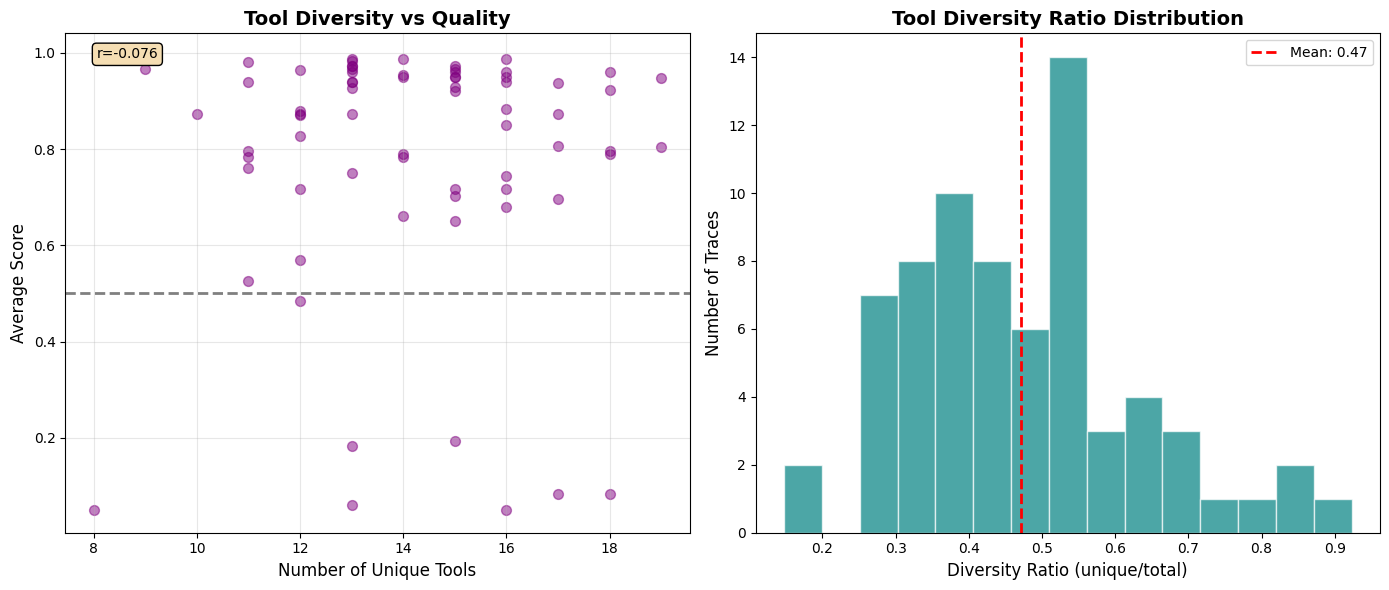

In [ ]:
# Tool Diversity - Does using more unique tools help?
if len(merged_df) > 0 and len(tool_sequences) > 0:
    unique_tools = {tid: len(set(seq)) for tid, seq in tool_sequences.items()}
    diversity_df = pd.DataFrame(list(unique_tools.items()), columns=['trace_id', 'unique_tools'])
    diversity_df['total_tools'] = [len(tool_sequences[tid]) for tid in diversity_df['trace_id']]
    diversity_df['diversity_ratio'] = diversity_df['unique_tools'] / diversity_df['total_tools']
    
    trace_avg_scores = merged_df.groupby('trace_id')['feedback_value'].mean().reset_index()
    trace_avg_scores.columns = ['trace_id', 'avg_score']
    diversity_quality = diversity_df.merge(trace_avg_scores, on='trace_id')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1 = axes[0]
    ax1.scatter(diversity_quality['unique_tools'], diversity_quality['avg_score'], alpha=0.5, c='purple', s=50)
    ax1.axhline(0.5, color='gray', linestyle='--', linewidth=2)
    ax1.set_xlabel('Number of Unique Tools', fontsize=12)
    ax1.set_ylabel('Average Score', fontsize=12)
    ax1.set_title('Tool Diversity vs Quality', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    from scipy.stats import spearmanr
    corr, p = spearmanr(diversity_quality['unique_tools'], diversity_quality['avg_score'])
    ax1.text(0.05, 0.95, f'r={corr:.3f}', transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat'))
    
    ax2 = axes[1]
    ax2.hist(diversity_quality['diversity_ratio'], bins=15, color='teal', alpha=0.7, edgecolor='white')
    ax2.axvline(diversity_quality['diversity_ratio'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {diversity_quality["diversity_ratio"].mean():.2f}')
    ax2.set_xlabel('Diversity Ratio (unique/total)', fontsize=12)
    ax2.set_ylabel('Number of Traces', fontsize=12)
    ax2.set_title('Tool Diversity Ratio Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()